# ImmoPilot Zürich — Exploratory Data Analysis (Numeric Block)

**Course**: AI Applications · ZHAW SML · Spring 2026
**Notebook**: `01_eda_numeric.ipynb`

This notebook explores the cleaned listings dataset (`features.parquet`, 664 rows × 33
columns) and the Stadt-Zürich median-rent table (`zurich_districts.parquet`). It
documents the key findings that motivate the modeling choices:

1. the right-skewed rent distribution → **log target**,
2. the strong rent ↔ location relationship,
3. the **Switzerland-wide vs. Zurich-city imbalance** (27 / 664) → the central limitation,
4. feature correlations and amenity effects.


## 0. Setup

In [1]:
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (8, 5)

DATA = ROOT / "data" / "processed"
print("Project root:", ROOT)
print("Data dir exists:", DATA.exists())

Project root: C:\Users\keris\Downloads\immopilot-zurich\immopilot-zurich
Data dir exists: True


## 1. Load data

In [2]:
df = pd.read_parquet(DATA / "features.parquet")
districts = pd.read_parquet(DATA / "zurich_districts.parquet")

print("Listings:", df.shape)
print("Districts (MPE):", districts.shape)
df.head()

Listings: (664, 33)
Districts (MPE): (12, 4)


,rent_chf,area_m2,rooms,plz,city,address,lat,lon,kreis,year_built,...,area_per_room,size_bucket,building_age,years_since_renovation,location_kreis,is_luxurious,is_furnished,is_temporary,condition_score,kitchen_quality
0,1920.0,82.0,3.0,8757,Filzbach,Alterstrasse 4,47.120462,9.131932,<NA>,2024.0,...,27.333333,m,2.0,NaN,other,0,0,0,0.5,0.5
1,750.0,45.0,1.0,5312,Döttingen,Hauptstr. 30 (Nord),47.570972,8.256332,<NA>,2009.0,...,45.000000,s,17.0,NaN,other,0,0,0,0.5,0.5
2,1970.0,88.0,3.5,8610,Uster,Falmenstrasse 2d,47.352412,8.718372,<NA>,2012.0,...,25.142857,m,14.0,NaN,other,0,0,0,0.5,0.5
3,2150.0,117.0,3.5,6010,Kriens,Am Mattenhof 2b,47.028212,8.301092,<NA>,2018.0,...,33.428571,l,8.0,NaN,other,0,0,0,0.5,0.5
4,2015.0,94.0,4.5,5636,Benzenschwil,Dorfstrasse 31,47.247752,8.365612,<NA>,2024.0,...,20.888889,m,2.0,NaN,other,0,0,0,0.5,0.5


## 2. Dataset overview

Shape, data types, and missing-value profile. Note that location-derived columns
(`kreis`, `rent_median_chf_per_m2`, …) are only populated for the Zurich rows, so high
missingness there is **expected**, not a data error.

In [3]:
print("Rows, columns:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)


Rows, columns: (664, 33)

Dtypes:
rent_chf                         float64
area_m2                          float64
rooms                            float64
plz                                Int64
city                              object
address                           object
lat                              float64
lon                              float64
kreis                              Int64
year_built                       float64
year_renovated                   float64
is_new_building                    Int64
has_balcony                        Int64
has_view                           Int64
has_elevator                       Int64
has_garage                         Int64
has_parking                        Int64
has_fireplace                      Int64
description                       object
is_zurich                           bool
rent_median_chf_per_m2           float64
rent_mean_chf_per_m2             float64
mpe_year                         float64
area_per_room          

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print(f"Zurich rows (is_zurich == True): {int(df['is_zurich'].sum())} / {len(df)}")

Columns with missing values:
mpe_year                  637
kreis                     637
rent_mean_chf_per_m2      637
rent_median_chf_per_m2    637
has_fireplace             566
years_since_renovation    466
year_renovated            466
has_view                  435
is_new_building           372
has_parking               345
has_garage                295
has_elevator              247
has_balcony               214
year_built                193
building_age              193
address                    94
dtype: int64

Zurich rows (is_zurich == True): 27 / 664


In [5]:
# Numeric summary of the key continuous variables
df[["rent_chf", "area_m2", "rooms", "year_built", "area_per_room"]].describe().round(1)

,rent_chf,area_m2,rooms,year_built,area_per_room
count,664.0,664.0,664.0,471.0,664.0
mean,1956.7,92.4,3.6,1991.5,26.0
std,969.5,37.0,1.1,45.7,7.7
min,560.0,18.0,1.0,1624.0,14.3
25%,1340.0,66.8,2.5,1972.0,21.8
50%,1723.0,88.0,3.5,2011.0,24.8
75%,2262.5,110.0,4.5,2022.0,28.0
max,10000.0,330.0,9.0,2025.0,142.0


## 3. Target distribution — `rent_chf`

The raw rent distribution is right-skewed (a long tail of expensive flats). A log
transform makes it roughly symmetric, which is why the models train on `log1p(rent)`
(`config.LOG_TARGET = True`).

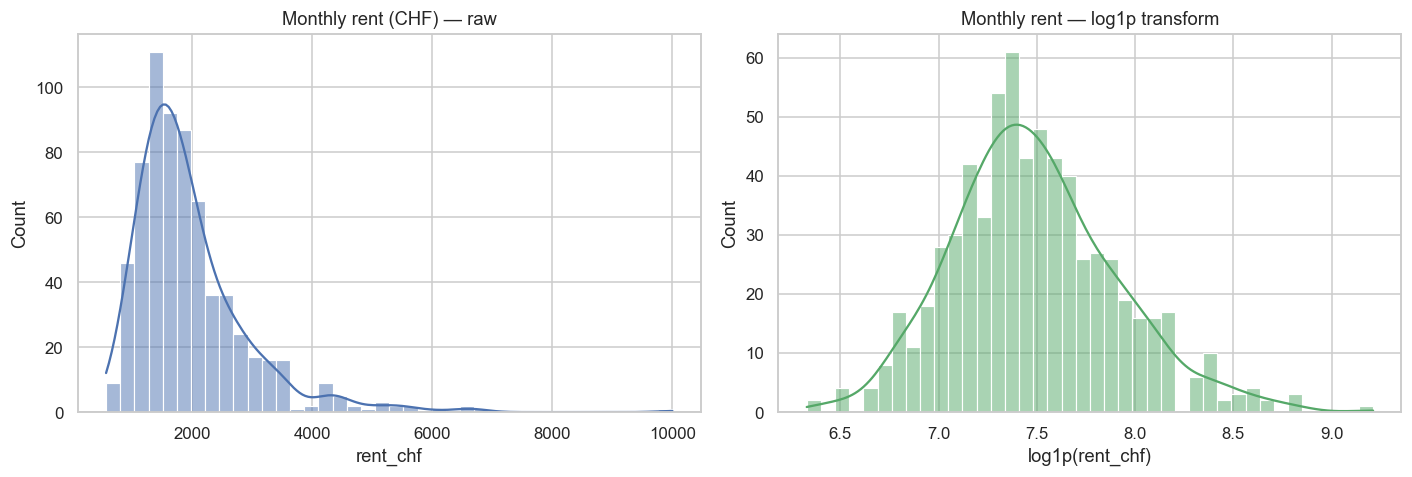

Skewness raw  : 2.41
Skewness log1p: 0.46


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["rent_chf"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Monthly rent (CHF) — raw")
axes[0].set_xlabel("rent_chf")

sns.histplot(np.log1p(df["rent_chf"]), bins=40, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Monthly rent — log1p transform")
axes[1].set_xlabel("log1p(rent_chf)")

plt.tight_layout()
plt.show()

print("Skewness raw  :", round(df["rent_chf"].skew(), 2))
print("Skewness log1p:", round(np.log1p(df["rent_chf"]).skew(), 2))

## 4. Rent vs. living area

Area is the strongest single continuous predictor of rent. The relationship is roughly
linear, with Zurich listings (orange) sitting above the Swiss-wide cloud at comparable
sizes — an early visual hint of the location premium.

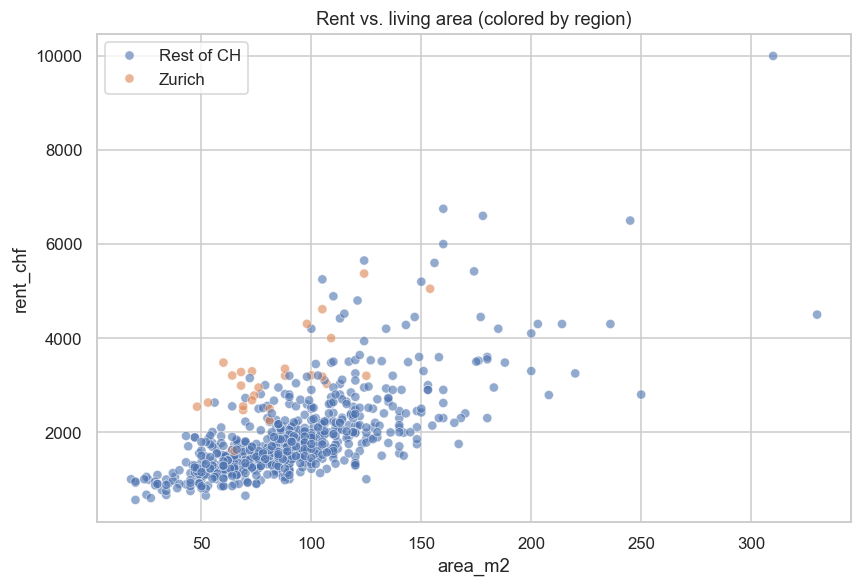

Pearson corr(area_m2, rent_chf) = 0.676


In [7]:
dfx = df.copy()
dfx["Region"] = dfx["is_zurich"].map({True: "Zurich", False: "Rest of CH"})

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(
    data=dfx, x="area_m2", y="rent_chf",
    hue="Region", alpha=0.6, ax=ax,
    palette={"Zurich": "#DD8452", "Rest of CH": "#4C72B0"},
)
ax.set_title("Rent vs. living area (colored by region)")
ax.set_xlabel("area_m2")
ax.set_ylabel("rent_chf")
ax.legend(title="")
plt.tight_layout()
plt.show()

corr_area = df[["area_m2", "rent_chf"]].corr().iloc[0, 1]
print(f"Pearson corr(area_m2, rent_chf) = {corr_area:.3f}")

## 5. Median rent per Kreis (Stadt-Zürich MPE 2024)

Using the official Mietpreiserhebung table (clean, 12 districts). This is the location
prior used in the hybrid calibration. The spread from Kreis 1 (most expensive) to
Kreis 12 (cheapest) is ~60 %.

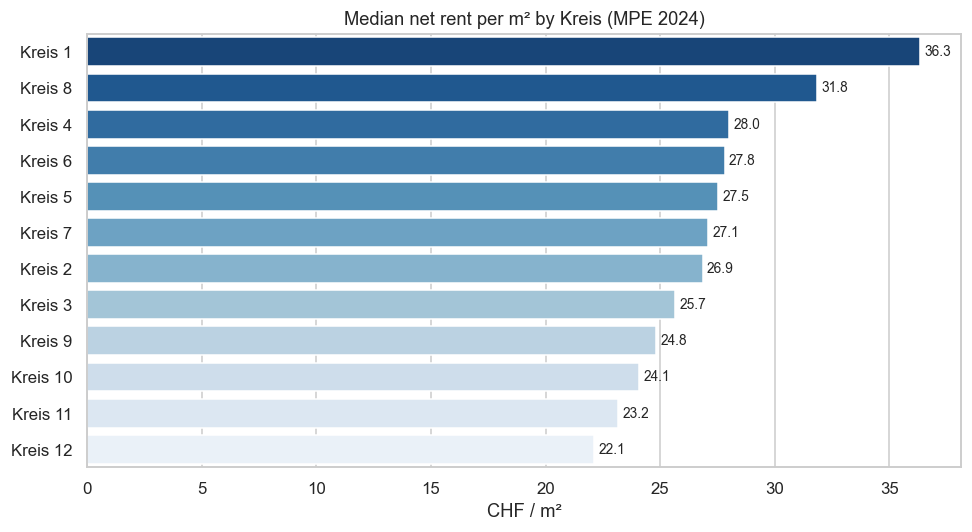

Spread cheapest→most expensive: 64%


In [8]:
d = districts.sort_values("rent_median_chf_per_m2", ascending=False).copy()
d["label"] = "Kreis " + d["kreis"].astype(str)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=d, y="label", x="rent_median_chf_per_m2", ax=ax,
            hue="label", legend=False, palette="Blues_r")
ax.set_title("Median net rent per m² by Kreis (MPE 2024)")
ax.set_xlabel("CHF / m²")
ax.set_ylabel("")
for i, v in enumerate(d["rent_median_chf_per_m2"]):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

spread = d["rent_median_chf_per_m2"].max() / d["rent_median_chf_per_m2"].min() - 1
print(f"Spread cheapest→most expensive: {spread*100:.0f}%")

## 6. The central data limitation — Zurich is under-represented

Only **27 of 664** rows lie within the city of Zurich. The model therefore learns a
Switzerland-average price surface and underestimates premium Zurich districts. This is
the motivation for the hybrid median calibration at inference time.

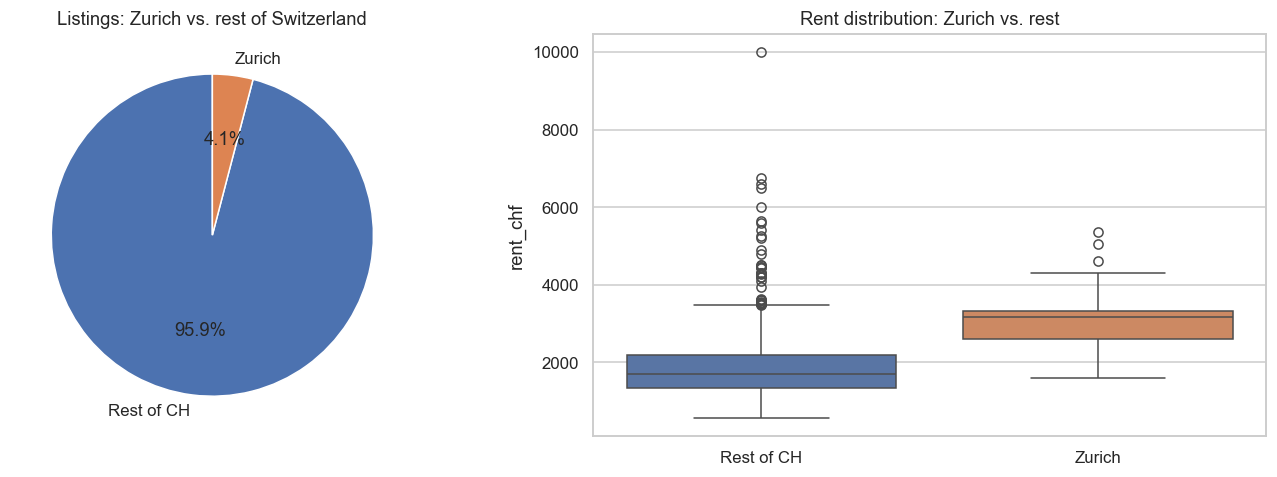

is_zurich
Rest of CH    637
Zurich         27
Name: count, dtype: int64

Median rent  Zurich: 3180
Median rent  Rest  : 1691


In [9]:
counts = df["is_zurich"].value_counts().rename({True: "Zurich", False: "Rest of CH"})

dfx = df.copy()
dfx["Region"] = dfx["is_zurich"].map({True: "Zurich", False: "Rest of CH"})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[0].set_title("Listings: Zurich vs. rest of Switzerland")

sns.boxplot(data=dfx, x="Region", y="rent_chf", ax=axes[1],
            hue="Region", legend=False,
            palette={"Zurich": "#DD8452", "Rest of CH": "#4C72B0"},
            order=["Rest of CH", "Zurich"])
axes[1].set_title("Rent distribution: Zurich vs. rest")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

print(counts)
print()
print("Median rent  Zurich:", int(df.loc[df['is_zurich'], 'rent_chf'].median()))
print("Median rent  Rest  :", int(df.loc[~df['is_zurich'], 'rent_chf'].median()))

## 7. Correlation matrix (numeric features)

Pearson correlations among the continuous features and the target. Area and room count
correlate most strongly with rent; amenity flags add smaller, independent signal.

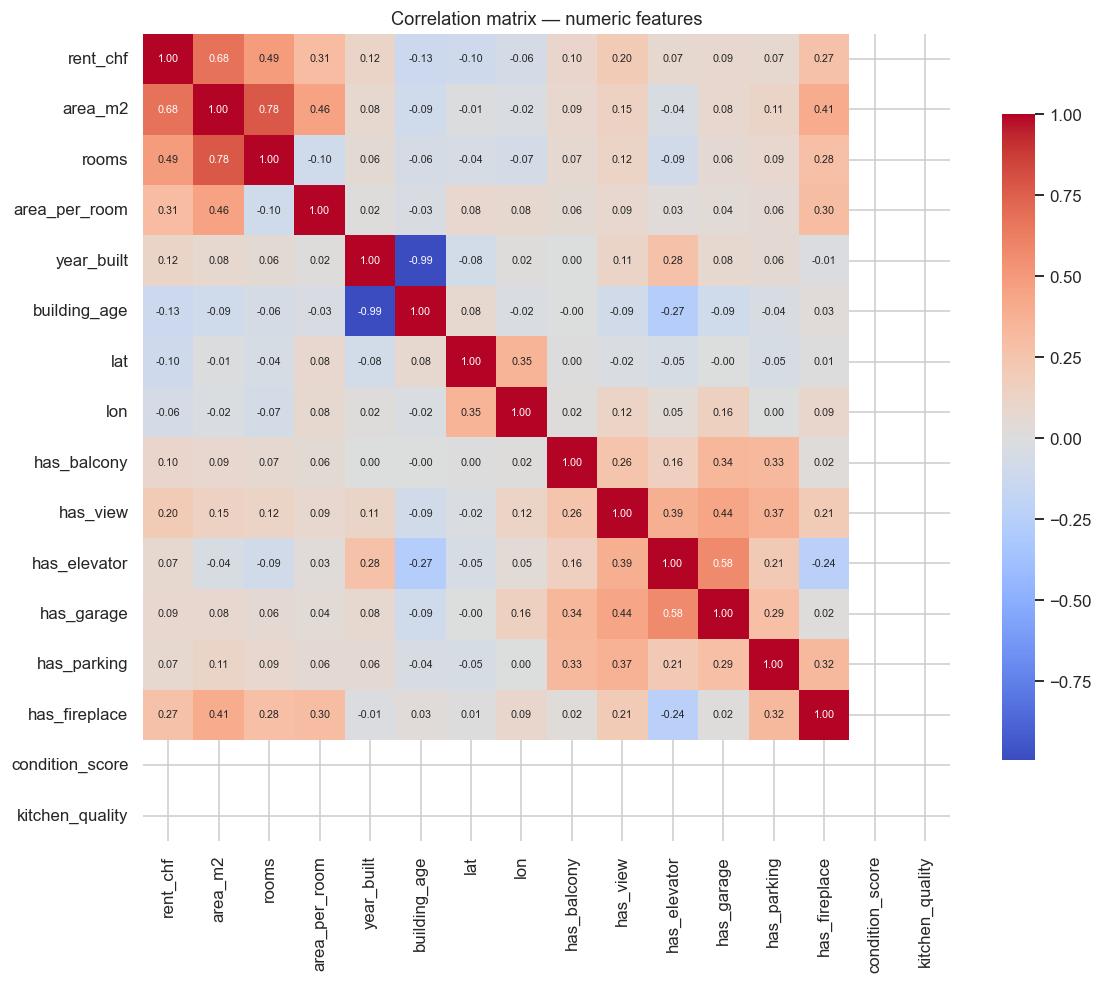

Top correlations with rent_chf:
area_m2          0.676
rooms            0.490
area_per_room    0.313
has_fireplace    0.271
has_view         0.200
building_age     0.125
year_built       0.116
has_balcony      0.102
Name: rent_chf, dtype: float64


In [10]:
num_cols = [
    "rent_chf", "area_m2", "rooms", "area_per_room",
    "year_built", "building_age", "lat", "lon",
    "has_balcony", "has_view", "has_elevator", "has_garage",
    "has_parking", "has_fireplace", "condition_score", "kitchen_quality",
]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].astype("float64").corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

print("Top correlations with rent_chf:")
print(corr["rent_chf"].drop("rent_chf").abs().sort_values(ascending=False).head(8).round(3))

## 8. Amenity effects on rent

Median rent with vs. without each amenity. Positive gaps confirm these binary flags
carry price-relevant signal, justifying their inclusion as model features.

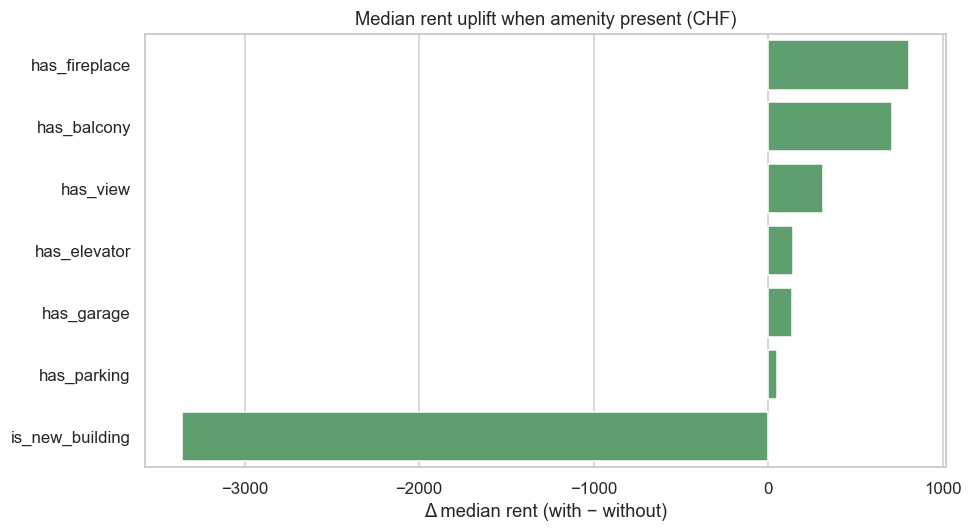

,amenity,with,without,delta
5,has_fireplace,2500.0,1690.0,810.0
0,has_balcony,1763.0,1055.0,708.0
1,has_view,1896.0,1580.0,316.0
2,has_elevator,1770.0,1624.0,146.0
3,has_garage,1750.0,1610.0,140.0
4,has_parking,1745.0,1695.0,50.0
6,is_new_building,1890.0,5250.0,-3360.0


In [11]:
amenities = ["has_balcony", "has_view", "has_elevator", "has_garage",
             "has_parking", "has_fireplace", "is_new_building"]
amenities = [a for a in amenities if a in df.columns]

rows = []
for a in amenities:
    with_a = df.loc[df[a] == 1, "rent_chf"].median()
    without_a = df.loc[df[a] == 0, "rent_chf"].median()
    rows.append({"amenity": a, "with": with_a, "without": without_a,
                 "delta": (with_a or 0) - (without_a or 0)})
amen_df = pd.DataFrame(rows).sort_values("delta", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=amen_df, y="amenity", x="delta", ax=ax, color="#55A868")
ax.set_title("Median rent uplift when amenity present (CHF)")
ax.set_xlabel("Δ median rent (with − without)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

amen_df.round(0)

## 9. Rooms and size structure

Distribution of room counts and the engineered `size_bucket`, plus how rent scales with
rooms. These confirm the dataset spans studios to large family flats.

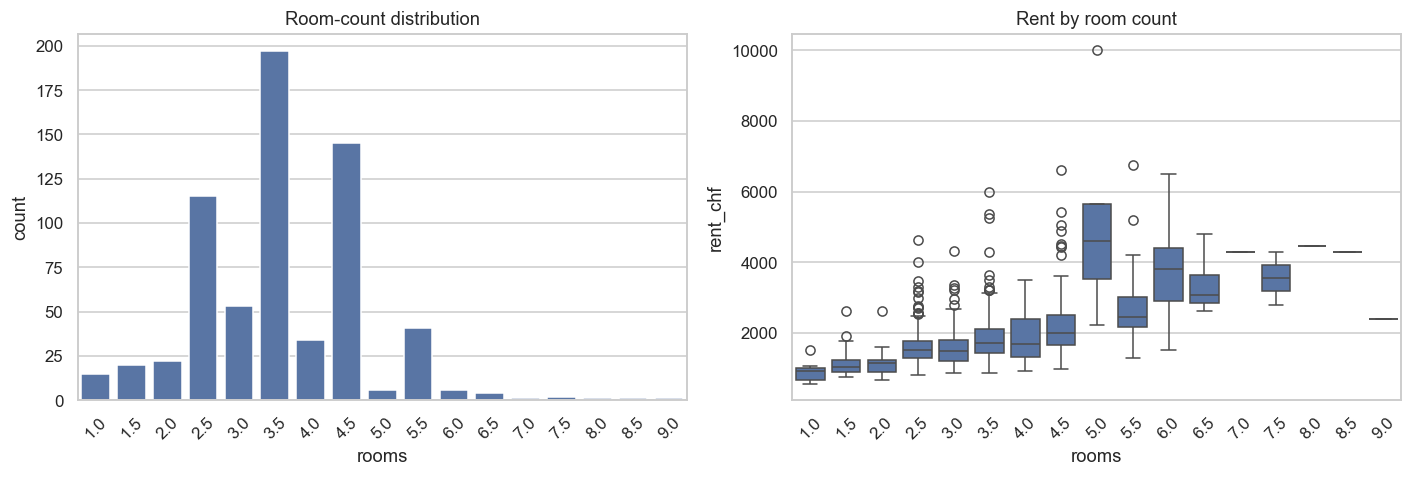

size_bucket counts:
size_bucket
m     227
l     201
s     133
xl     77
xs     26
Name: count, dtype: Int64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="rooms", ax=axes[0], color="#4C72B0")
axes[0].set_title("Room-count distribution")
axes[0].set_xlabel("rooms")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="rooms", y="rent_chf", ax=axes[1], color="#4C72B0")
axes[1].set_title("Rent by room count")
axes[1].set_xlabel("rooms")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

if "size_bucket" in df.columns:
    print("size_bucket counts:")
    print(df["size_bucket"].value_counts())

## 10. Data quality & outlier handling

The cleaning step (`data/load_listings.py::basic_outlier_filter`) keeps rents within
**CHF 500–12'000**. Below we confirm the post-filter range and inspect the most
extreme remaining values, which are plausible high-end flats rather than artifacts.

In [13]:
print("Rent range after filtering:", int(df["rent_chf"].min()), "–", int(df["rent_chf"].max()))
print()
print("5 highest rents (sanity check):")
cols = [c for c in ["rent_chf", "area_m2", "rooms", "city", "is_zurich"] if c in df.columns]
print(df.nlargest(5, "rent_chf")[cols].to_string(index=False))

Rent range after filtering: 560 – 10000

5 highest rents (sanity check):
 rent_chf  area_m2  rooms     city  is_zurich
  10000.0    310.0    5.0   Genève      False
   6750.0    160.0    5.5   Coppet      False
   6600.0    178.0    4.5     Bern      False
   6500.0    245.0    6.0    Féchy      False
   6000.0    160.0    3.5 Massagno      False


## 11. Summary of findings

- **Right-skewed target** → log transform (`log1p`) is justified; skewness drops from
  the raw value toward ~0.
- **Area is the dominant predictor**; rooms and area-per-room add structure.
- **Location matters strongly**: the MPE table shows a ~60 % spread across Kreise, and
  Zurich listings sit above the Swiss-wide cloud.
- **Central limitation**: only 27/664 rows are in Zurich, so the model underestimates
  premium districts — addressed via hybrid median calibration at inference.
- **Amenities** (view, fireplace, garage, …) carry measurable, independent price signal,
  supporting their use as features.

These findings are consistent with the modeling results in `DOCUMENTATION.md §4`
(XGBoost test MAE 337 CHF, R² 0.78; SHAP dominated by location and area).